<a href="https://colab.research.google.com/github/Ragha112/Raghavendra-portfolio/blob/main/PORTFOLIO_OPTIMIZATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#MEAN- VARIANCE PORTFOLIO OPTIMIZATION

In [11]:
!pip -q install yfinance cvxpy

import numpy as np
import pandas as pd
import yfinance as yf
import cvxpy as cp
import matplotlib.pyplot as plt

In [27]:
tickers = [
    "AAPL","MSFT","GOOGL","AMZN","META",
    "NVDA","TSLA","BRK-B","JPM","V",
    "MA","UNH","HD","PG","XOM",
    "KO","PEP","AVGO","COST","MRK",
    "ABBV","ADBE","CRM","TMO","LIN"
]   # change to Indian tickers if you want
start = "2020-01-01"
end   = "2026-01-01" # till latest

prices = yf.download(tickers, start=start, end=end, auto_adjust=True)["Close"]
prices = prices.dropna()
prices.tail()

[*********************100%***********************]  25 of 25 completed


Ticker,AAPL,ABBV,ADBE,AMZN,AVGO,BRK-B,COST,CRM,GOOGL,HD,...,MRK,MSFT,NVDA,PEP,PG,TMO,TSLA,UNH,V,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-24,273.554016,228.055130,352.980011,232.380005,350.220001,501.339996,870.670532,265.260010,314.089996,347.339996,...,106.449997,486.908630,188.610001,143.740005,143.471359,579.119995,485.399994,327.579987,354.409180,118.430618
2025-12-26,273.144409,228.144394,353.799988,232.520004,352.130005,498.299988,872.158447,266.079987,313.510010,349.779999,...,106.779999,486.599365,190.529999,143.779999,143.719589,580.739990,475.190002,331.829987,354.269470,118.321342
2025-12-29,273.504089,228.997543,353.160004,232.070007,349.390015,501.049988,866.656067,266.230011,313.559998,347.450012,...,106.620003,485.990753,188.220001,144.240005,143.550797,585.070007,459.640015,328.940002,353.880249,119.731941
2025-12-30,272.824707,227.906326,352.510010,232.529999,349.850006,503.709991,864.469055,265.920013,313.850006,346.350006,...,106.059998,486.369904,187.539993,144.160004,143.034454,583.450012,454.429993,332.160004,352.892303,120.188896
2025-12-31,271.605835,226.666306,349.989990,230.820007,346.100006,502.649994,861.163574,264.910004,313.000000,344.100006,...,105.260002,482.518677,186.500000,143.520004,142.299667,579.450012,449.720001,330.109985,349.988281,119.543198


In [28]:
# daily returns
rets = prices.pct_change().dropna()

# annualize (approx 252 trading days)
mu = rets.mean().values * 252
Sigma = rets.cov().values * 252

mu, Sigma.shape

(array([0.2715888 , 0.22973393, 0.07913025, 0.21228121, 0.51836989,
        0.15454391, 0.22466909, 0.15422207, 0.30830084, 0.13901953,
        0.21488865, 0.09160423, 0.16330681, 0.15549668, 0.28989057,
        0.0928311 , 0.23666239, 0.71650771, 0.06435581, 0.07122602,
        0.13967701, 0.68111946, 0.09373865, 0.14517265, 0.18891497]),
 (25, 25))

In [29]:
n = len(tickers)
rf = 0.02  # 2% risk-free rate (annual) - you can change

# constraints: sum(w)=1, w>=0
w = cp.Variable(n)

def solve_min_variance_for_target(target_return):
    objective = cp.Minimize(cp.quad_form(w, Sigma))
    constraints = [
    cp.sum(w) == 1,
    w >= 0,
    w <= 0.10,     # max 10% per stock
    mu @ w >= target_return
]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, verbose=False)
    if w.value is None:
        return None
    return w.value

# scan target returns
target_returns = np.linspace(mu.min()*0.6, mu.max()*1.05, 40)

port_rets = []
port_vols = []
port_sharpes = []
port_ws = []

for tr in target_returns:
    w_star = solve_min_variance_for_target(tr)
    if w_star is None:
        continue
    rp = float(mu @ w_star)
    vp = float(w_star.T @ Sigma @ w_star)
    sp = (rp - rf) / np.sqrt(vp)

    port_rets.append(rp)
    port_vols.append(np.sqrt(vp))
    port_sharpes.append(sp)
    port_ws.append(w_star)

best_idx = int(np.argmax(port_sharpes))
best_w = port_ws[best_idx]
best_ret = port_rets[best_idx]
best_vol = port_vols[best_idx]
best_sharpe = port_sharpes[best_idx]

best_w, best_sharpe

(array([ 4.48895275e-02,  1.00001158e-01, -1.05861888e-06, -1.83050894e-07,
         1.00004285e-01,  9.99998049e-02,  1.00000686e-01, -2.44294843e-07,
         1.00001258e-01, -2.02833536e-07,  2.07447100e-02,  5.79112700e-02,
         1.16294480e-07,  5.22694524e-08,  6.75814602e-04,  7.57604905e-02,
         5.57000626e-07,  1.00006319e-01, -5.06108785e-07, -7.10709880e-07,
        -1.08139264e-07,  1.00007024e-01, -3.83817874e-07, -1.13152723e-07,
         1.00000448e-01]),
 np.float64(1.3617501225827067))

In [30]:
weights_df = pd.DataFrame({
    "Ticker": tickers,
    "Weight": best_w
}).sort_values("Weight", ascending=False)

weights_df["Weight %"] = (weights_df["Weight"] * 100).round(2)
weights_df.reset_index(drop=True, inplace=True)
weights_df

,Ticker,Weight,Weight %
0,ADBE,1.000070e-01,10.00
1,AVGO,1.000063e-01,10.00
2,META,1.000043e-01,10.00
3,JPM,1.000013e-01,10.00
4,MSFT,1.000012e-01,10.00
5,TSLA,1.000007e-01,10.00
6,LIN,1.000004e-01,10.00
7,NVDA,9.999980e-02,10.00
8,KO,7.576049e-02,7.58
9,UNH,5.791127e-02,5.79


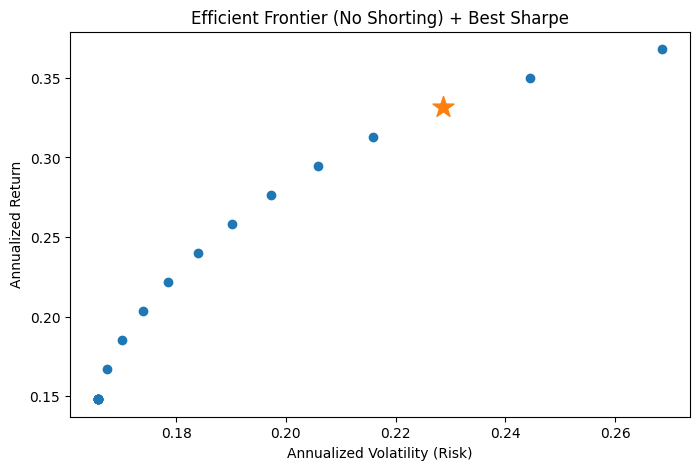

Best Sharpe Portfolio
Return: 0.3314
Volatility: 0.2287
Sharpe: 1.3618
Ticker        Weight  Weight %
  ADBE  1.000070e-01     10.00
  AVGO  1.000063e-01     10.00
  META  1.000043e-01     10.00
   JPM  1.000013e-01     10.00
  MSFT  1.000012e-01     10.00
  TSLA  1.000007e-01     10.00
   LIN  1.000004e-01     10.00
  NVDA  9.999980e-02     10.00
    KO  7.576049e-02      7.58
   UNH  5.791127e-02      5.79
  AAPL  4.488953e-02      4.49
    MA  2.074471e-02      2.07
   XOM  6.758146e-04      0.07
   PEP  5.570006e-07      0.00
    HD  1.162945e-07      0.00
    PG  5.226945e-08      0.00
  ABBV -1.081393e-07     -0.00
   TMO -1.131527e-07     -0.00
  AMZN -1.830509e-07     -0.00
     V -2.028335e-07     -0.00
 BRK-B -2.442948e-07     -0.00
   CRM -3.838179e-07     -0.00
  COST -5.061088e-07     -0.00
   MRK -7.107099e-07     -0.00
 GOOGL -1.058619e-06     -0.00


In [31]:
plt.figure(figsize=(8,5))
plt.scatter(port_vols, port_rets)
plt.scatter([best_vol], [best_ret], marker="*", s=250)  # best sharpe
plt.xlabel("Annualized Volatility (Risk)")
plt.ylabel("Annualized Return")
plt.title("Efficient Frontier (No Shorting) + Best Sharpe")
plt.show()

print("Best Sharpe Portfolio")
print("Return:", round(best_ret, 4))
print("Volatility:", round(best_vol, 4))
print("Sharpe:", round(best_sharpe, 4))
print(weights_df.to_string(index=False))

In [32]:
# Equal weight portfolio
w_eq = np.ones(len(tickers)) / len(tickers)

ret_eq = float(mu @ w_eq)
vol_eq = float(np.sqrt(w_eq.T @ Sigma @ w_eq))
sharpe_eq = (ret_eq - rf) / vol_eq

print("Equal Weight Portfolio")
print("Return:", round(ret_eq,4))
print("Volatility:", round(vol_eq,4))
print("Sharpe:", round(sharpe_eq,4))

Equal Weight Portfolio
Return: 0.2255
Volatility: 0.2113
Sharpe: 0.9723


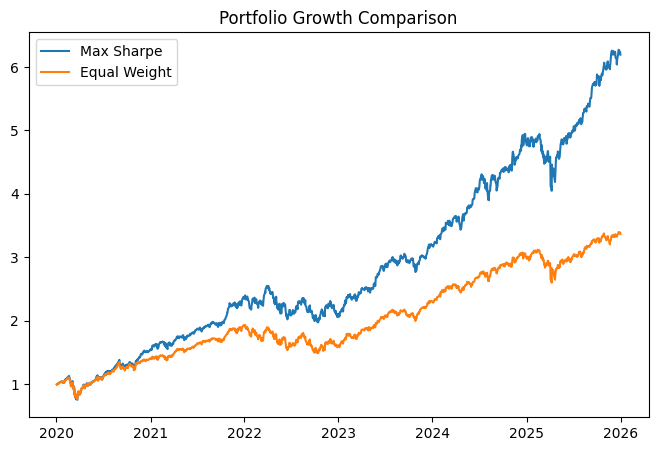

In [33]:
# Compute portfolio daily returns
port_daily = rets @ best_w
eq_daily = rets @ w_eq

# cumulative growth
growth_opt = (1 + port_daily).cumprod()
growth_eq = (1 + eq_daily).cumprod()

plt.figure(figsize=(8,5))
plt.plot(growth_opt, label="Max Sharpe")
plt.plot(growth_eq, label="Equal Weight")
plt.legend()
plt.title("Portfolio Growth Comparison")
plt.show()

In [34]:
num_random = 200000
n = len(tickers)

alpha = 0.2  # smaller = more concentrated portfolios
W = np.random.dirichlet(alpha*np.ones(n), size=num_random)

rand_rets = W @ mu
rand_vars = np.einsum('ij,jk,ik->i', W, Sigma, W)
rand_vols = np.sqrt(rand_vars)
rand_sharpes = (rand_rets - rf) / rand_vols


In [35]:
best_w_clean = np.clip(best_w, 0, None)
best_w_clean = best_w_clean / best_w_clean.sum()

weights_df = pd.DataFrame({"Ticker": tickers, "Weight": best_w_clean})
weights_df["Weight %"] = (weights_df["Weight"] * 100)
weights_df = weights_df.sort_values("Weight", ascending=False)
weights_df.head(12)

,Ticker,Weight,Weight %
21,ADBE,0.100007,10.000667
17,AVGO,0.100006,10.000597
4,META,0.100004,10.000393
8,JPM,0.100001,10.000091
1,MSFT,0.100001,10.000081
6,TSLA,0.100000,10.000033
24,LIN,0.100000,10.000010
5,NVDA,0.099999,9.999945
15,KO,0.075760,7.576022
11,UNH,0.057911,5.791107


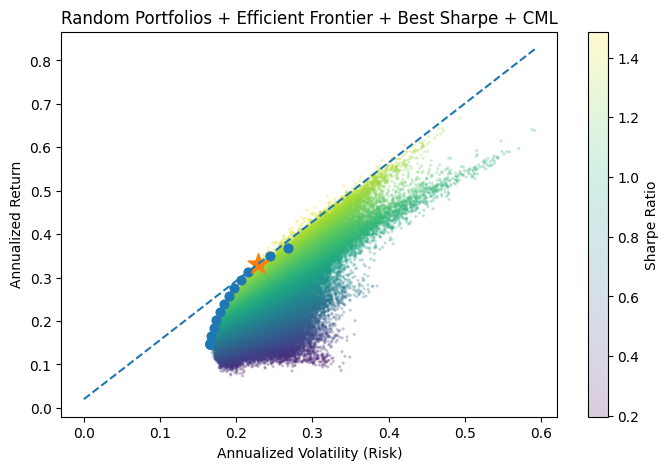

In [37]:
plt.figure(figsize=(8,5))

# Random portfolios
sc = plt.scatter(rand_vols, rand_rets, c=rand_sharpes, s=2, alpha=0.2)

# Efficient frontier
plt.scatter(port_vols, port_rets, s=40)

# Best Sharpe
plt.scatter([best_vol], [best_ret], marker="*", s=250)

# Capital Market Line
cml_x = np.linspace(0, max(rand_vols), 100)
cml_y = rf + best_sharpe * cml_x
plt.plot(cml_x, cml_y, linestyle='--')

plt.xlabel("Annualized Volatility (Risk)")
plt.ylabel("Annualized Return")
plt.title("Random Portfolios + Efficient Frontier + Best Sharpe + CML")
plt.colorbar(sc, label="Sharpe Ratio")

plt.show()

In [38]:
#RISK PARITY

In [39]:
import numpy as np
import pandas as pd

def risk_parity_weights(Sigma, max_iter=5000, tol=1e-10, step=0.01):
    """
    Long-only risk parity via iterative updates (simple and robust for 20-100 assets).
    Sigma: covariance matrix (n x n)
    """
    n = Sigma.shape[0]
    w = np.ones(n) / n  # start equal weight

    for _ in range(max_iter):
        # portfolio variance and marginal risk
        port_var = float(w.T @ Sigma @ w)
        port_vol = np.sqrt(port_var)
        mrc = (Sigma @ w) / port_vol                 # marginal risk contribution
        rc = w * mrc                                 # risk contributions
        target = port_vol / n                        # equal target RC

        # gradient-like update: push RCs toward target
        diff = rc - target
        w_new = w - step * diff

        # enforce long-only and fully invested
        w_new = np.clip(w_new, 0, None)
        if w_new.sum() == 0:
            w_new = np.ones(n) / n
        else:
            w_new = w_new / w_new.sum()

        # check convergence
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new

    return w

In [40]:
import numpy as np
import pandas as pd

def risk_parity_weights(Sigma, max_iter=5000, tol=1e-10, step=0.01):
    """
    Long-only risk parity via iterative updates (simple and robust for 20-100 assets).
    Sigma: covariance matrix (n x n)
    """
    n = Sigma.shape[0]
    w = np.ones(n) / n  # start equal weight

    for _ in range(max_iter):
        # portfolio variance and marginal risk
        port_var = float(w.T @ Sigma @ w)
        port_vol = np.sqrt(port_var)
        mrc = (Sigma @ w) / port_vol                 # marginal risk contribution
        rc = w * mrc                                 # risk contributions
        target = port_vol / n                        # equal target RC

        # gradient-like update: push RCs toward target
        diff = rc - target
        w_new = w - step * diff

        # enforce long-only and fully invested
        w_new = np.clip(w_new, 0, None)
        if w_new.sum() == 0:
            w_new = np.ones(n) / n
        else:
            w_new = w_new / w_new.sum()

        # check convergence
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new

    return w

In [41]:
w_rp = risk_parity_weights(Sigma)

weights_rp_df = pd.DataFrame({
    "Ticker": tickers,
    "Weight": w_rp
}).sort_values("Weight", ascending=False)

weights_rp_df["Weight %"] = (weights_rp_df["Weight"] * 100).round(2)
weights_rp_df.head(15)

,Ticker,Weight,Weight %
19,MRK,0.061882,6.19
15,KO,0.061583,6.16
11,UNH,0.059489,5.95
1,MSFT,0.057845,5.78
18,COST,0.053067,5.31
6,TSLA,0.049381,4.94
24,LIN,0.047380,4.74
5,NVDA,0.047299,4.73
22,CRM,0.042457,4.25
20,ABBV,0.042169,4.22


In [42]:
port_vol = np.sqrt(float(w_rp.T @ Sigma @ w_rp))
rc = (w_rp * (Sigma @ w_rp)) / port_vol

rc_df = pd.DataFrame({
    "Ticker": tickers,
    "Weight %": (w_rp * 100),
    "RiskContrib %": (rc / rc.sum()) * 100
}).sort_values("RiskContrib %", ascending=False)

rc_df[["Ticker","Weight %","RiskContrib %"]].head(15)

,Ticker,Weight %,RiskContrib %
18,COST,5.306712,4.000274
22,CRM,4.245687,4.000181
20,ABBV,4.216926,4.000173
5,NVDA,4.729925,4.000168
12,HD,4.079103,4.000151
24,LIN,4.738007,4.000141
9,V,3.777820,4.000106
6,TSLA,4.938122,4.000092
23,TMO,3.600835,4.000085
10,MA,3.635063,4.000079


In [43]:
def port_stats(w, mu, Sigma, rf):
    r = float(mu @ w)
    v = float(np.sqrt(w.T @ Sigma @ w))
    s = (r - rf) / v
    return r, v, s

ret_rp, vol_rp, sharpe_rp = port_stats(w_rp, mu, Sigma, rf)

print("Risk Parity Portfolio")
print("Return:", round(ret_rp, 4))
print("Volatility:", round(vol_rp, 4))
print("Sharpe:", round(sharpe_rp, 4))

Risk Parity Portfolio
Return: 0.1949
Volatility: 0.1924
Sharpe: 0.909


In [45]:
# ---- Add Max Weight Constraint ----
cap = 0.08   # 8% max per stock (change to 0.10 if you want)

w_cap = np.minimum(w_rp, cap)
w_cap = w_cap / w_cap.sum()  # renormalize

# Recompute portfolio stats
ret_cap, vol_cap, sharpe_cap = port_stats(w_cap, mu, Sigma, rf)

print("Risk Parity (Capped)")
print("Return:", round(ret_cap, 4))
print("Volatility:", round(vol_cap, 4))
print("Sharpe:", round(sharpe_cap, 4))

Risk Parity (Capped)
Return: 0.1949
Volatility: 0.1924
Sharpe: 0.909


In [46]:
port_vol_cap = np.sqrt(float(w_cap.T @ Sigma @ w_cap))
rc_cap = (w_cap * (Sigma @ w_cap)) / port_vol_cap

rc_df_cap = pd.DataFrame({
    "Ticker": tickers,
    "Weight %": (w_cap * 100),
    "RiskContrib %": (rc_cap / rc_cap.sum()) * 100
}).sort_values("RiskContrib %", ascending=False)

rc_df_cap.head(15)

,Ticker,Weight %,RiskContrib %
18,COST,5.306712,4.000274
22,CRM,4.245687,4.000181
20,ABBV,4.216926,4.000173
5,NVDA,4.729925,4.000168
12,HD,4.079103,4.000151
24,LIN,4.738007,4.000141
9,V,3.777820,4.000106
6,TSLA,4.938122,4.000092
23,TMO,3.600835,4.000085
10,MA,3.635063,4.000079


In [47]:
#CVAR OPTIMIZATION

In [48]:
import cvxpy as cp

alpha = 0.95
T, N = rets.shape

R = rets.values  # daily returns matrix

w = cp.Variable(N)
z = cp.Variable(T)
gamma = cp.Variable()

# Portfolio losses
portfolio_returns = R @ w
losses = -portfolio_returns

# CVaR objective
objective = gamma + (1/(T*(1-alpha))) * cp.sum(z)

constraints = [
    z >= 0,
    z >= losses - gamma,
    cp.sum(w) == 1,
    w >= 0
]

prob = cp.Problem(cp.Minimize(objective), constraints)
prob.solve()

w_cvar = w.value

In [49]:
ret_cvar, vol_cvar, sharpe_cvar = port_stats(w_cvar, mu, Sigma, rf)

print("CVaR Portfolio")
print("Return:", round(ret_cvar,4))
print("Volatility:", round(vol_cvar,4))
print("Sharpe:", round(sharpe_cvar,4))

CVaR Portfolio
Return: 0.1323
Volatility: 0.1636
Sharpe: 0.6864


In [50]:
port_daily_cvar = rets @ w_cvar
var_95 = np.percentile(port_daily_cvar, 5)
cvar_95 = port_daily_cvar[port_daily_cvar <= var_95].mean()

print("VaR 95%:", round(var_95,4))
print("CVaR 95%:", round(cvar_95,4))

VaR 95%: -0.0141
CVaR 95%: -0.0233


In [51]:
#BLACK-LITTERMAN

In [55]:
# ---- BLACK-LITTERMAN ----

tau = 0.05

# Assume market weights = equal weight
w_mkt = np.ones(len(tickers)) / len(tickers)

# Compute implied equilibrium returns
pi = mu.copy()   # use historical expected returns as prior

# Example view:
# "NVDA will outperform by 5% annually"
P = np.zeros((1, len(tickers)))
idx_nvda = tickers.index("NVDA")
P[0, idx_nvda] = 1

q = np.array([0.05])  # 5% excess return view
Omega = np.array([[0.01]])  # uncertainty

# Black-Litterman posterior return
middle = np.linalg.inv(np.linalg.inv(tau*Sigma) + P.T @ np.linalg.inv(Omega) @ P)
mu_bl = middle @ (np.linalg.inv(tau*Sigma) @ pi + P.T @ np.linalg.inv(Omega) @ q)

In [56]:
# Optimize with BL returns

w_bl = cp.Variable(len(tickers))

objective = cp.Minimize(cp.quad_form(w_bl, Sigma))
constraints = [
    cp.sum(w_bl) == 1,
    w_bl >= 0,
    mu_bl @ w_bl >= mu_bl.mean()
]

prob = cp.Problem(objective, constraints)
prob.solve()

w_bl = w_bl.value

In [57]:
ret_bl, vol_bl, sharpe_bl = port_stats(w_bl, mu_bl, Sigma, rf)

print("Black-Litterman Portfolio")
print("Return:", round(ret_bl,4))
print("Volatility:", round(vol_bl,4))
print("Sharpe:", round(sharpe_bl,4))

Black-Litterman Portfolio
Return: 0.2116
Volatility: 0.1734
Sharpe: 1.1054


In [58]:
#BACKTEST

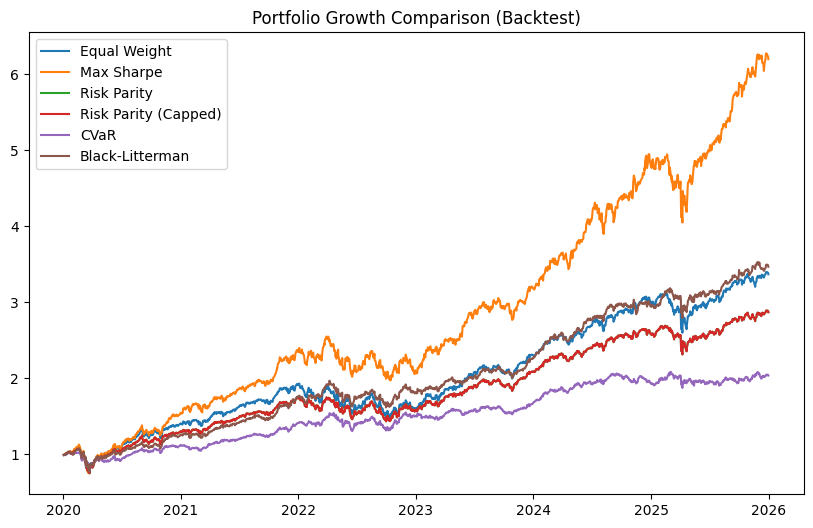

In [59]:
# -------- BACKTEST COMPARISON (CUMULATIVE GROWTH) --------

w_eq = np.ones(len(tickers)) / len(tickers)

port_eq      = rets @ w_eq
port_sharpe  = rets @ best_w
port_rp      = rets @ w_rp
port_rp_cap  = rets @ w_cap
port_cvar    = rets @ w_cvar
port_bl      = rets @ w_bl

growth_eq     = (1 + port_eq).cumprod()
growth_sharpe = (1 + port_sharpe).cumprod()
growth_rp     = (1 + port_rp).cumprod()
growth_rp_cap = (1 + port_rp_cap).cumprod()
growth_cvar   = (1 + port_cvar).cumprod()
growth_bl     = (1 + port_bl).cumprod()

plt.figure(figsize=(10,6))
plt.plot(growth_eq, label="Equal Weight")
plt.plot(growth_sharpe, label="Max Sharpe")
plt.plot(growth_rp, label="Risk Parity")
plt.plot(growth_rp_cap, label="Risk Parity (Capped)")
plt.plot(growth_cvar, label="CVaR")
plt.plot(growth_bl, label="Black-Litterman")

plt.legend()
plt.title("Portfolio Growth Comparison (Backtest)")
plt.show()

In [60]:
def max_drawdown(series):
    peak = series.cummax()
    dd = (series/peak) - 1
    return dd.min()

results = pd.DataFrame({
    "Portfolio": ["Equal", "MaxSharpe", "RiskParity", "RP_Cap", "CVaR", "BlackLitterman"],
    "MaxDD": [
        max_drawdown(growth_eq),
        max_drawdown(growth_sharpe),
        max_drawdown(growth_rp),
        max_drawdown(growth_rp_cap),
        max_drawdown(growth_cvar),
        max_drawdown(growth_bl),
    ]
})
results

,Portfolio,MaxDD
0,Equal,-0.309661
1,MaxSharpe,-0.334197
2,RiskParity,-0.301705
3,RP_Cap,-0.301705
4,CVaR,-0.244970
5,BlackLitterman,-0.278441
